In [1]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split

In [2]:
DATASET_PATH = 'dataset_glitches/'
TRAIN_PATH = os.path.join(DATASET_PATH, 'train')
TEST_PATH = os.path.join(DATASET_PATH, 'test')
train_imgs = [os.path.join(TRAIN_PATH, 'images', img_name) for img_name in os.listdir(TRAIN_PATH + '/images')]
train_masks = [os.path.join(TRAIN_PATH, 'masks', img_name) for img_name in os.listdir(TRAIN_PATH + '/masks')]
len(train_imgs), len(train_masks)

(200, 200)

In [3]:
train_img_paths, val_img_paths, train_masks, val_masks = train_test_split(train_imgs, train_masks, test_size=0.2)
len(train_img_paths), len(val_img_paths), len(train_masks), len(val_masks)

(160, 40, 160, 40)

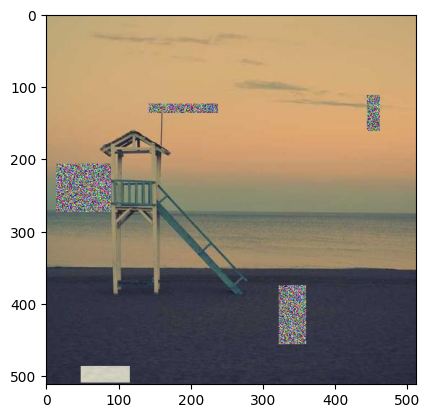

In [4]:
example = Image.open(train_imgs[1])
plt.imshow(example)

In [24]:
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

transform = A.Compose([
    A.HorizontalFlip(0.5),
    A.VerticalFlip(0.5),
    A.ShiftScaleRotate(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    ToTensorV2()
])

class ImageDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform):
        super().__init__()
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)
    
    def __getitem__(self, idx):
        img = np.array(Image.open(self.img_paths[idx])) / 255.0
        mask = (np.array(Image.open(self.mask_paths[idx])) / 255.0)
        mask = (mask > 0.5).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"].float()
            mask = augmented["mask"].float()
            mask = mask.unsqueeze(0)
        else:
            img = torch.tensor(img, dtype=torch.float32)
            mask = torch.tensor(mask, dtype=torch.float32)
        return img, mask
    
ds_train = ImageDataset(train_img_paths, train_masks, transform)
ds_val = ImageDataset(val_img_paths, val_masks, transform)
train_loader = DataLoader(ds_train, batch_size=4, shuffle=True)
val_loader = DataLoader(ds_val, batch_size=4)

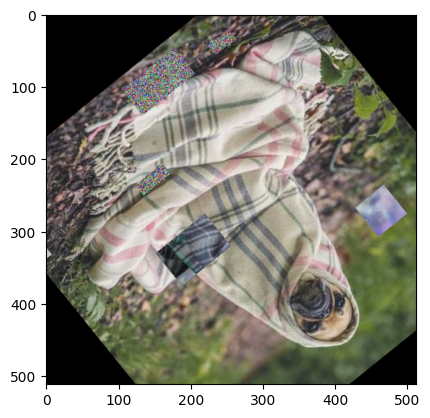

In [25]:
img, mask = ds_train[0]
img.shape, mask.shape
plt.imshow(img.permute(1,2,0))

In [ ]:
def double_conv(in_ch, out_ch, dropout = 0):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
    )
 
 
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=2, base_features=64):
        super().__init__()
        f = base_features
 
        # Encoder
        self.enc1 = double_conv(in_channels, f)
        self.enc2 = double_conv(f,     f * 2)
        self.enc3 = double_conv(f * 2, f * 4)
 
        # Bottleneck
        self.bottleneck = double_conv(f * 4, f * 8, 0.1)
 
        # Decoder
        self.dec3 = double_conv(f * 8 + f * 4, f * 4)
        self.dec2 = double_conv(f * 4 + f * 2, f * 2)
        self.dec1 = double_conv(f * 2 + f,     f)
 
        # Output
        self.out = nn.Conv2d(f, out_channels, kernel_size=1)
 
        self.pool = nn.MaxPool2d(2)
 
    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
 
        # Bottleneck
        b = self.bottleneck(self.pool(e3))
 
        # Decoder
        d3 = self.dec3(torch.cat([e3, F.interpolate(b,  size=e3.shape[2:], mode="bilinear", align_corners=False)], dim=1))
        d2 = self.dec2(torch.cat([e2, F.interpolate(d3, size=e2.shape[2:], mode="bilinear", align_corners=False)], dim=1))
        d1 = self.dec1(torch.cat([e1, F.interpolate(d2, size=e1.shape[2:], mode="bilinear", align_corners=False)], dim=1))
 
        return self.out(d1)

In [8]:
# from torchinfo import summary
# model = UNet(3, 1, base_features=32)
# summary(model, input_size=(8,3,256,256))

In [26]:
from tqdm import tqdm
epochs = 30
patiance = 5
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = UNet(3, 1, base_features=16).to(device)
criterion = nn.BCEWithLogitsLoss()
optim = torch.optim.AdamW(model.parameters(), lr=1e-4)

for epoch in tqdm(range(epochs)):
    train_loss = 0
    for (img, mask) in train_loader:
        img, mask = img.to(device), mask.to(device)
        preds = model(img)
        loss = criterion(preds, mask)

        loss.backward()
        optim.step()
        optim.zero_grad()

        train_loss += loss.item() * len(mask)

    train_loss/=len(ds_train)

    val_loss = 0
    with torch.no_grad():
        for (img, mask) in val_loader:
            img, mask = img.to(device), mask.to(device)
            preds = model(img)
            loss = criterion(preds, mask)

            val_loss += loss.item() * len(mask)

    val_loss/=len(ds_val)

    print(f'Epoch: {epoch}/{epochs} | Train loss: {train_loss} | Val loss: {val_loss}')

  3%|▎         | 1/30 [00:07<03:49,  7.93s/it]

Epoch: 0/30 | Train loss: 0.5568687565624714 | Val loss: 0.316658216714859


  7%|▋         | 2/30 [00:16<03:46,  8.08s/it]

Epoch: 1/30 | Train loss: 0.27007811293005946 | Val loss: 0.23367323577404023


 10%|█         | 3/30 [00:25<03:57,  8.79s/it]

...

Epoch: 13/30 | Train loss: 0.13874105047434568 | Val loss: 0.11469395682215691


 50%|█████     | 15/30 [02:13<02:14,  8.98s/it]

Epoch: 14/30 | Train loss: 0.14157815538346769 | Val loss: 0.1258804477751255


 50%|█████     | 15/30 [02:16<02:16,  9.10s/it]


KeyboardInterrupt: 